In [1]:
import math
import os
from dog import LDoG
from dog import PolynomialDecayAverager
from untils.data_split import DataSplit
import numpy as np
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"
import torch
import torchvision.transforms
from torch.utils.data import DataLoader
import statistics
from data_loaders.segmentation_dataset import SegmentationDataset
from models.big_unet import UNet
from untils.loss import MixedLoss
from untils.test import evaluate, metric
from untils.train import EarlyStopping, train_one_epoch
import math
import sys

In [2]:
sunny_summer=[ 'nf4123_016.png',
 'nf4123_017.png',
'nf4123_018.png',
'nf4123_019.png',
'nf4123_020.png',
'nf4123_021.png',
'nf4123_022.png',
 'nf4123_023.png',
 'nf4123_024.png',
 'nf4123_025','nf4321_154.png','nf4321_155.png',
'nf4321_156.png',
'nf4321_157.png',
'nf4321_158.png']

In [3]:
EPOCHS = 100#15#70#15#19
TRAIN_MODEL = True
EVALUATE = True
#N_CLASS = 11
N_CLASS = 11
N_BANDS = 25

ds = DataSplit()
test, val, train = ds.get_files("./assets")

data_path = "/dsi/scratch/home/dsi/yanivz_datasets/HSI_Drive_v2_01/Image_dataset/cubes_fl32"

labels_path = "/dsi/scratch/home/dsi/yanivz_datasets/HSI_Drive_v2_01/Image_dataset/labels"

train_dataset = SegmentationDataset(
    image_dir=data_path,
    n_class=N_CLASS,
    mask_dir=labels_path,
    mode="Hyper",
    data_key="cube",
    samples_names=train,
    transform=None,
)
train_dataset
#train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)


In [4]:
#'nf4321_154.png'


In [5]:
arr= np.array(train_dataset[0]["image"])[7,:,:]

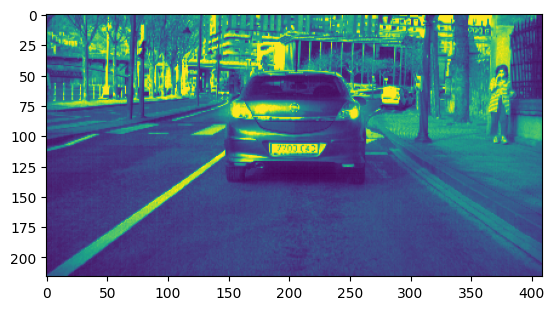

In [6]:
import matplotlib.pyplot as plt 
plt.imshow(arr)

In [7]:
import numpy as np
import os
from collections import Counter
from torch.utils.data import Dataset, DataLoader

class TiledSegmentationDataset(Dataset):
    def __init__(self, original_dataset, tile_size=16,tran=None):
        self.original_dataset = original_dataset
        self.tile_size = tile_size
        self.tran = tran
        self.tiles = self._extract_tiles()
    def _extract_tiles(self):
        tiles = []
        for data in self.original_dataset:
            #print(image,label)
            image=data["image"] if self.tran == None else self.tran(data["image"])
            label=data["mask"]
            c, h, w = image.shape  # Adjusted to handle channel first
            for i in range(0, h, self.tile_size):
                for j in range(0, w, self.tile_size):
                    tile_image = image[:, i:i+self.tile_size, j:j+self.tile_size]  # Slicing height and width
                    tile_label = label[i:i+self.tile_size, j:j+self.tile_size]
                    if tile_image.shape[1] == self.tile_size and tile_image.shape[2] == self.tile_size:
                        tiles.append((tile_image, tile_label))
        return tiles

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        return self.tiles[idx]

def get_most_popular_label(tile_label, threshold=0.6):
    flat_labels = tile_label.flatten()
    label_counts = Counter(flat_labels)
    most_common_label, count = label_counts.most_common(1)[0]
    if count / len(flat_labels) > threshold:
        return most_common_label
    else:
        return 'undefined'

# Example usage:
image_paths = ['path/to/image1.npy', 'path/to/image2.npy', ...]
label_paths = ['path/to/label1.npy', 'path/to/label2.npy', ...]
print("here")
#original_dataset = OriginalSegmentationDataset(image_paths, label_paths)
tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16)
print("out of")
len(tiled_dataset)
# # Directories to save the tiles
# output_dir = 'path/to/save/tiles'
# os.makedirs(output_dir, exist_ok=True)

# for idx, (tile_image, tile_label) in enumerate(tiled_dataset):
#     most_popular_label = get_most_popular_label(tile_label)
#     label_dir = os.path.join(output_dir, str(most_popular_label))
#     os.makedirs(label_dir, exist_ok=True)
    
#     np.save(os.path.join(label_dir, f'tile_image_{idx}.npy'), tile_image)
#     np.save(os.path.join(label_dir, f'tile_label_{idx}.npy'), tile_label)


here
out of


171275

In [8]:
# class TiledSegmentationDataset(Dataset):
#     def __init__(self, original_dataset, tile_size=32):
#         self.original_dataset = original_dataset
#         self.tile_size = tile_size
#         self.tiles = self._extract_tiles()

#     def _extract_tiles(self):
#         tiles = []
#         for data in self.original_dataset:
#             image=data["image"]
#             label=data["mask"]
#             c, h, w = image.shape  # Adjusted to handle channel first
#             for i in range(0, h, self.tile_size):
#                 for j in range(0, w, self.tile_size):
#                     tile_image = image[:, i:i+self.tile_size, j:j+self.tile_size]  # Slicing height and width
#                     tile_label = label[i:i+self.tile_size, j:j+self.tile_size]
#                     if tile_image.shape[1] == self.tile_size and tile_image.shape[2] == self.tile_size:
#                         tiles.append((tile_image, tile_label))
#         return tiles

#     def __len__(self):
#         return len(self.tiles)

#     def __getitem__(self, idx):
#         return self.tiles[idx]

# tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=4)


In [9]:
print("jojoojo")

jojoojo


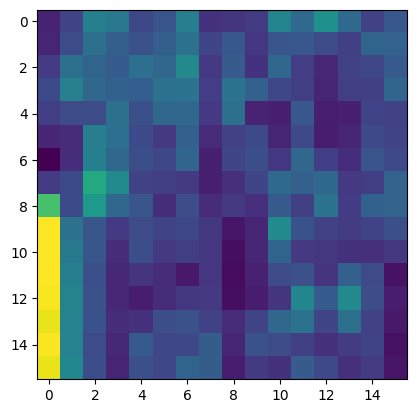

In [10]:
plt.imshow(tiled_dataset[5][0][7,:,:])
#tiled_dataset[3][0][:].shape

In [11]:
len(tiled_dataset)

171275

In [12]:
#images = [image1, image2, image3, image4, image5]

#plt.figure(figsize=(15, 5))

for i in range(2000,2010):
    img = tiled_dataset[i][0][7,:,:]
    plt.subplot(2001, 2011,1+ i )
    plt.imshow(img)
    plt.axis('off')

plt.show()


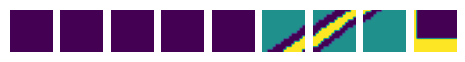

In [13]:
for i in range(201,210):
    img = tiled_dataset[i][1][:,:]
    plt.subplot(1, 10,1+ i -201)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [14]:
tiled_dataset[209][1][:,:]


tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [46]:
def get_most_popular_label(tile_label, threshold=0.9):
    flat_labels = np.array(tile_label).flatten()
    label_counts = Counter(flat_labels)
    #print(label_counts)
    most_common_label, count = label_counts.most_common(1)[0]
    #if most_common_label==0:
        #print(label_counts.most_common(2))
    #    return label_counts.most_common(2)[-1][0]
    #print(count,len(flat_labels),count / len(flat_labels))
    if count / len(flat_labels) > threshold:
        return most_common_label
    else:
        return 0#'undefined'
myl=Counter()
for i in range(0,len(tiled_dataset)-2):
    lb = tiled_dataset[i][1][:,:]
    myl[get_most_popular_label(lb)]+=1
myl

Counter({0: 93505,
         4: 671,
         1: 53053,
         6: 2657,
         5: 4694,
         3: 16163,
         9: 25,
         2: 316,
         10: 76,
         7: 110,
         8: 3})

In [47]:
myl[10]

76

In [49]:
import numpy as np
labels=range(0,11)
class_sample_count = np.array([myl[t] for t in np.unique(labels)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in labels])

samples_weight = torch.from_numpy(samples_weight)
samples_weight = samples_weight.double()
samples_weight[0]=0
samples_weight

tensor([0.0000e+00, 1.8849e-05, 3.1646e-03, 6.1870e-05, 1.4903e-03, 2.1304e-04,
        3.7636e-04, 9.0909e-03, 3.3333e-01, 4.0000e-02, 1.3158e-02],
       dtype=torch.float64)

In [50]:
class FilteredTileDataset(Dataset):
    def __init__(self, tile_dataset,bad_labels=[0,'undefined']):
        self.filtered_tiles = [
            tile for i,tile in enumerate(tile_dataset)
            if (get_most_popular_label(tile[1][:,:])!=bad_labels[0] and get_most_popular_label(tile[1][:,:])!=bad_labels[1])
        ]

    def __len__(self):
        return len(self.filtered_tiles)

    def __getitem__(self, idx):
        return self.filtered_tiles[idx]
fl=FilteredTileDataset(tiled_dataset)
len(fl)

77770

In [51]:
sum(list(myl.values()))#-23011 54099 

171273

In [52]:
fl=FilteredTileDataset(tiled_dataset)
len(fl)

77770

In [53]:
len(fl)+myl[0]+myl['undefined']

171275

In [54]:
from torch import nn



class Embedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv3d(1,3,(3,3,3))
        self.max1=nn.MaxPool3d(3, stride=2,padding=0)
        self.conv2=nn.Conv3d(3,6,(2,2,2))
        self.max2=nn.MaxPool3d(3, stride=2,padding=0)
        self.projection_head = nn.Linear(96 , 64)

    def forward(self, x):
        #x = self.backbone(x).flatten(start_dim=1)
        x= self.max2(self.conv2(self.max1(self.conv1(x))))
        print(x.shape)
        x = x.flatten(dim=1)
        z = self.projection_head(x)
        return z
#net=Embedder()
#net(tiled_dataset[0][0]).shape
#tiled_dataset[0][0].shape
#net(torch.zeros((6,25,16,16)).shape)

In [55]:
import torch
import torch.nn as nn

class Embedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 3, (3, 3, 3))
        self.max1 = nn.MaxPool3d(3, stride=2, padding=0)
        self.conv2 = nn.Conv3d(3, 6, (2, 2, 2))
        self.max2 = nn.MaxPool3d(3, stride=2, padding=0)
        
        self.projection_head = nn.Linear(96, 64)  # Adjusted input dimension

    def forward(self, x):
        #print("x0",x.shape)
        #if len(x.shape)==3:
        #    x=x.unsqueeze(0)
        x = self.max1(self.conv1(x))
        #print("x1",x.shape)
        x = self.conv2(x)
        x = self.max2(x)
        #print("x2",x.shape)
        #x = x.view(x.size(0), -1)  # Flatten starting from the batch dimension
        #print(x.shape)
        #print("x3",x.shape)
        z = self.projection_head(x.view(x.size(0), -1))
        return z

# Example usage
embedder = Embedder()
input_tensor = torch.randn(64,1,25, 16, 16)  # Batch size 64, 1 channel, depth 25, height 16, width 16
output = embedder(input_tensor)
print(output.shape)  # Should print torch.Size([64, 64])

torch.Size([64, 64])


(tensor(6400), torch.Size([25, 16, 16]))

torch.Size([8, 96])


tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True])

In [58]:
class ToNumpy:
    def __call__(self, sample):
        if isinstance(sample, torch.Tensor):
            return sample.numpy()
        elif isinstance(sample, (tuple, list)):
            return [s.numpy() if isinstance(s, torch.Tensor) else s for s in sample]
        else:
            raise TypeError(f"Expected input sample to be torch.Tensor or a tuple/list of torch.Tensors, got {type(sample)}")

# Example usage of the custom transform
to_numpy_transform = ToNumpy()


In [59]:
# ignored_labels=[0,'undefined']
# tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CNIFAR10(root='./data', train=True, download=True, transform=transform)
# #train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# # Filter out the indices with the ignored labels
# bad_dix= [i for i, label in enumerate(tiled_dataset.targets) if label in ignored_labels]
# print("bad_dix",len(bad_dix))

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import copy
class TwoCropTransform:
    """Create two crops of the same image"""
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return [self.transform(x), self.transform(x)]
# transform1 = transforms.Compose([
#     #ToNumpy(),
#     transforms.RandomResizedCrop(16),
#     transforms.RandomHorizontalFlip(),
#     #transforms.ToTensor(),
# ])
shift_limit=0.1
zoom_limit=1.2
my_shear=0.01
two_crops=TwoCropTransform(transforms.Compose([
    #ToNumpy(),
    transforms.RandomResizedCrop(16),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    # transforms.RandomAffine(
    #     degrees=0,
    #     translate=(shift_limit, shift_limit),
    #     scale=(1.0, zoom_limit)
    # ),
    transforms.RandomAffine(
        degrees=0,
        shear=my_shear * 180 / 3.14159  # convert radians to degrees
    )
    #transforms.ToTensor(),
]))
class Predictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Predictor, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

# BYOL training step
# def byol_training_step(online_net, target_net, predictor, data, optimizer, tau=0.99):
#     img1, img2 = data
#     print(img1.shape)#, img2.shape)# =img1, img2
#     # Forward pass through online and target networks
#     z1_online = predictor(online_net(img1))
#     z2_online = predictor(online_net(img2))
#     with torch.no_grad():
#         z1_target = target_net(img1)
#         z2_target = target_net(img2)
    
#     # Loss calculation
#     loss = nn.MSELoss()(z1_online, z2_target) + nn.MSELoss()(z2_online, z1_target)
    
#     # Backpropagation
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
    
#     # EMA update for target network
#     for online_param, target_param in zip(online_net.parameters(), target_net.parameters()):
#         target_param.data = tau * target_param.data + (1 - tau) * online_param.data
    
#     return loss.item()

# Main training loop
# BYOL training step
def byol_training_step(online_net, target_net, predictor, img1, img2, optimizer, tau=0.99):
    # Forward pass through online and target networks
    z1_online = predictor(online_net(img1))
    z2_online = predictor(online_net(img2))
    with torch.no_grad():
        z1_target = target_net(img1)
        z2_target = target_net(img2)
    
    # Loss calculation
    loss = nn.MSELoss()(z1_online, z2_target) + nn.MSELoss()(z2_online, z1_target)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # EMA update for target network
    for online_param, target_param in zip(online_net.parameters(), target_net.parameters()):
        target_param.data = tau * target_param.data + (1 - tau) * online_param.data
    
    return loss.item()

# Main training loop
def train_byol(online_net, target_net, predictor, train_loader, epochs, device, lr=0.0001):# lr=0.001
    optimizer = optim.Adam(list(online_net.parameters()) + list(predictor.parameters()), lr=lr)
    for epoch in range(epochs):
        print(f'Start epc {epoch}')
        epc_loss=0
        n_batch=0
        online_net.train()
        predictor.train()
        for batch in train_loader:
            print(len(batch[1]))
            #print((batch[1]
            img1,img2 = two_crops(batch[0])#, batch[0][1].to(device)
            #print(img1.shape,img2.shape)
            img1,img2 =img1.squeeze().unsqueeze(1),img2.squeeze().unsqueeze(1)
            #print(img1.shape,img2.shape)

            loss = byol_training_step(online_net, target_net, predictor,img1.to(device),img2.to(device), optimizer)#pay ettention- will create probelms for different size
            #print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')
            epc_loss+=loss
            n_batch+=1
        print(f'Total Epoch [{epoch+1}/{epochs}], Loss: {epc_loss/n_batch:.6f}')
  


# Data augmentation and loading
print("1234")
ignored_labels=[0,'undefined']
tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CNIFAR10(root='./data', train=True, download=True, transform=transform)
fl_tiled_dataset=FilteredTileDataset(tiled_dataset)
#train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
from torch.utils.data import WeightedRandomSampler
batch_size=65
sampler = WeightedRandomSampler(samples_weight,len(samples_weight))
train_loader = torch.utils.data.DataLoader(fl_tiled_dataset, batch_size=64,sampler=sampler)

# Initialize networks
online_net = Embedder().to("cuda")
target_net = copy.deepcopy(online_net).to("cuda")
predictor = Predictor(64, 128, 64).to("cuda")

# Train BYOL
train_byol(online_net, target_net, predictor, train_loader, epochs=25,device="cuda")


1234
Start epc 0
11
Total Epoch [1/25], Loss: 0.086137
Start epc 1
11
Total Epoch [2/25], Loss: 0.054079
Start epc 2
11
Total Epoch [3/25], Loss: 0.087736
Start epc 3
11
Total Epoch [4/25], Loss: 0.151859
Start epc 4
11


/home/dsi/yanivz/miniconda3/envs/bs/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Total Epoch [5/25], Loss: 0.106585
Start epc 5
11
Total Epoch [6/25], Loss: 0.083352
Start epc 6
11
Total Epoch [7/25], Loss: 0.098649
Start epc 7
11
Total Epoch [8/25], Loss: 0.066834
Start epc 8
11
Total Epoch [9/25], Loss: 0.081606
Start epc 9
11
Total Epoch [10/25], Loss: 0.049763
Start epc 10
11
Total Epoch [11/25], Loss: 0.075014
Start epc 11
11
Total Epoch [12/25], Loss: 0.072338
Start epc 12
11
Total Epoch [13/25], Loss: 0.061096
Start epc 13
11
Total Epoch [14/25], Loss: 0.099979
Start epc 14
11
Total Epoch [15/25], Loss: 0.057986
Start epc 15
11
Total Epoch [16/25], Loss: 0.073818
Start epc 16
11
Total Epoch [17/25], Loss: 0.074214
Start epc 17
11
Total Epoch [18/25], Loss: 0.093364
Start epc 18
11
Total Epoch [19/25], Loss: 0.079425
Start epc 19
11
Total Epoch [20/25], Loss: 0.052449
Start epc 20
11
Total Epoch [21/25], Loss: 0.045400
Start epc 21
11
Total Epoch [22/25], Loss: 0.068028
Start epc 22
11
Total Epoch [23/25], Loss: 0.077766
Start epc 23
11
Total Epoch [24/25], L

KNN

In [61]:
import numpy as np
from collections import Counter
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

def most_common_label_batch(label_maps):
    # Reshape label_maps to (batch_size, -1) to flatten each 16x16 map
    flattened_maps = label_maps.reshape(label_maps.shape[0], -1)
    # Use mode function from scipy.stats to find the most common label for each label map
    mode_labels, _ = stats.mode(flattened_maps, axis=1)
    return mode_labels.flatten()

my_embeddings = []
my_labels = []
to_knn_loader=torch.utils.data.DataLoader(fl_tiled_dataset, batch_size=64)#train_loader#fl_tiled_dataset#FilteredTileDataset(tiled_dataset)
dummy_net=Embedder().to("cuda")
#for i in range(10000):
for batch in to_knn_loader:
    #print(batch[0].shape,len(batch))
    if batch[0].shape[0]!=64:
         break
    img=batch[0].to("cuda")
    labels =batch[1] #, batch[0][1].to(device)
    #print(img.shape,labels.shape)
    
    common_label = most_common_label_batch(labels)
    embedding = target_net(img.squeeze().unsqueeze(1))
    #embedding = dummy_net(img.squeeze().unsqueeze(1))
    #print("common_label",common_label.shape,"embedding",embedding.shape)
    #print(embedding.shape)
    my_embeddings.append(np.array(embedding.detach().cpu().numpy()))
    my_labels.append(np.array(common_label))
# Convert to numpy arrays
stacked_array = np.vstack(my_embeddings)
print(np.array(my_embeddings).shape,stacked_array.shape)
embeddings = np.array(stacked_array)
print("embeddings.shape=",embeddings.shape)

stacked_labels = np.concatenate(my_labels)
print(np.array(stacked_labels).shape,stacked_labels.shape)
labels = np.array(stacked_labels)
print("labels.shape",labels.shape,embeddings.shape)


/tmp/ipykernel_2134638/1187566561.py:12: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode_labels, _ = stats.mode(flattened_maps, axis=1)


(1215, 64, 64) (77760, 64)
embeddings.shape= (77760, 64)
(77760,) (77760,)
labels.shape (77760,) (77760, 64)


In [62]:
balanced_emb=[]
balanced_labels=[]
for i in range(1,11):
    balanced_emb.extend(embeddings[labels==i][:5])
    balanced_labels.extend(labels[labels==i][:5])
balanced_labels

[1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 9,
 9,
 9,
 9,
 9,
 10,
 10,
 10,
 10,
 10]

In [63]:
labels[40000:40100]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=0)
X_train, y_train=balanced_emb,balanced_labels
#X_train, X_test, y_train, y_test = embeddings[:60000], stacked_labels[:60000],embeddings[60000:], stacked_labels[60000:]
# Create and train the KNN model
print("training...")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print classification report
print(classification_report(y_test, y_pred))


training...
Accuracy: 0.15
              precision    recall  f1-score   support

           1       0.75      0.13      0.22     10612
           2       0.01      0.24      0.01        59
           3       0.36      0.14      0.20      3274
           4       0.10      0.05      0.07       130
           5       0.26      0.35      0.30       911
           6       0.05      0.17      0.07       526
           7       0.00      0.29      0.00        21
           8       0.00      0.00      0.00         1
           9       0.01      0.14      0.01         7
          10       0.00      0.64      0.00        11

    accuracy                           0.15     15552
   macro avg       0.15      0.21      0.09     15552
weighted avg       0.61      0.15      0.21     15552



In [33]:
gpt

NameError: name 'gpt' is not defined

In [ ]:
import numpy as np
from collections import Counter

# Assuming embedder is a function that takes a 16x16 image tile and returns a 64-dimensional embedding
def embedder(tile):
    # Dummy function for illustration
    return np.random.rand(64)+np.max(tile)

# Example tile and label map
tiles = np.random.rand(100, 16, 16, 3)
tiles[50:] = 1+tiles[50:] # 100 image tiles of size 16x16 with 3 channels
labels_map = np.random.randint(0, 10, (100, 16, 16))  # 100 label maps of size 16x16 with labels between 0 and 9

# Function to find the most common label in a label map
def most_common_label(label_map):
    label_counts = Counter(label_map.flatten())
    return label_counts.most_common(1)[0][0]

# Initialize lists to hold embeddings and labels
embeddings = []
labels = []

# Loop through each tile and label map
for tile, label_map in zip(tiles, labels_map):
    embedding = embedder(tile)
    common_label = most_common_label(label_map)
    embeddings.append(embedding)
    labels.append(common_label)

# Convert to numpy arrays
embeddings = np.array(embeddings)
labels = np.array(labels)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42)

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print classification report
print(classification_report(y_test, y_pred))


In [ ]:
# #tiled_dataset = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)# datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# class TwoCropTransform:
#     """Create two crops of the same image"""
#     def __init__(self, transform):
#         self.transform = transform

#     def __call__(self, x):
#         return [self.transform(x), self.transform(x)]

# tiled_dataset2 = TiledSegmentationDataset(train_dataset, tile_size=16,tran=None)#
# train_loader2 = torch.utils.data.DataLoader(tiled_dataset2, batch_size=64, shuffle=True)


In [ ]:
# for batch in train_loader2:
#     print(len(batch))#.shape)
#     print(batch[0].shape)
#     print(batch[1].shape)
#     img1, img2 = batch[0][0], batch[0][1]
#     print(img1.shape,img2.shape)
#     break


In [ ]:
print("done")

In [ ]:
#0.6 threshold
Total Epoch [1/10], Loss: 0.015145
Start epc 1
Total Epoch [2/10], Loss: 0.015122
Start epc 2
Total Epoch [3/10], Loss: 0.013334
Start epc 3
Total Epoch [4/10], Loss: 0.011713
Start epc 4
Total Epoch [5/10], Loss: 0.010727
Start epc 5
Total Epoch [6/10], Loss: 0.008473
Start epc 6
Total Epoch [7/10], Loss: 0.007713
Start epc 7
Total Epoch [8/10], Loss: 0.006757
Start epc 8
Total Epoch [9/10], Loss: 0.006136
Start epc 9
Total Epoch [10/10], Loss: 0.005559

#0.7 threshold - 92086 samples
Total Epoch [1/25], Loss: 0.009742
Start epc 1
Total Epoch [2/25], Loss: 0.014496
Start epc 2
Total Epoch [3/25], Loss: 0.013149
Start epc 3
Total Epoch [4/25], Loss: 0.012504
Start epc 4
Total Epoch [5/25], Loss: 0.011440
Start epc 5
Total Epoch [6/25], Loss: 0.011217
Start epc 6
Total Epoch [7/25], Loss: 0.010146
Start epc 7
Total Epoch [8/25], Loss: 0.009717
Start epc 8
Total Epoch [9/25], Loss: 0.008792
Start epc 9
Total Epoch [10/25], Loss: 0.008313
Start epc 10
Total Epoch [11/25], Loss: 0.007612
Start epc 11
Total Epoch [12/25], Loss: 0.007304
Start epc 12
Total Epoch [13/25], Loss: 0.006814
Start epc 13
Total Epoch [14/25], Loss: 0.006126
Start epc 14
Total Epoch [15/25], Loss: 0.005739
Start epc 15
Total Epoch [16/25], Loss: 0.004999
Start epc 16
Total Epoch [17/25], Loss: 0.004733
Start epc 17
Total Epoch [18/25], Loss: 0.004322
Start epc 18
Total Epoch [19/25], Loss: 0.003859
Start epc 19
Total Epoch [20/25], Loss: 0.003894
Start epc 20
Total Epoch [21/25], Loss: 0.003664
Start epc 21
Total Epoch [22/25], Loss: 0.003319
Start epc 22
Total Epoch [23/25], Loss: 0.003338
Start epc 23
Total Epoch [24/25], Loss: 0.003055
Start epc 24
Total Epoch [25/25], Loss: 0.002832


#0.8 85345 samples 
Total Epoch [1/25], Loss: 0.005815
Start epc 1
Total Epoch [2/25], Loss: 0.006983
Start epc 2
Total Epoch [3/25], Loss: 0.006046
Start epc 3
Total Epoch [4/25], Loss: 0.005720
Start epc 4
Total Epoch [5/25], Loss: 0.004729
Start epc 5
Total Epoch [6/25], Loss: 0.004523
Start epc 6
Total Epoch [7/25], Loss: 0.003852
Start epc 7
Total Epoch [8/25], Loss: 0.003480
Start epc 8
Total Epoch [9/25], Loss: 0.003364
Start epc 9
Total Epoch [10/25], Loss: 0.002876
Start epc 10
Total Epoch [11/25], Loss: 0.002830
Start epc 11
Total Epoch [12/25], Loss: 0.002613
Start epc 12
Total Epoch [13/25], Loss: 0.002473
Start epc 13
Total Epoch [14/25], Loss: 0.002354
Start epc 14
Total Epoch [15/25], Loss: 0.002334
Start epc 15
Total Epoch [16/25], Loss: 0.002277
Start epc 16
Total Epoch [17/25], Loss: 0.002013
Start epc 17
Total Epoch [18/25], Loss: 0.001961
Start epc 18
Total Epoch [19/25], Loss: 0.001954
Start epc 19
Total Epoch [20/25], Loss: 0.001858
Start epc 20
Total Epoch [21/25], Loss: 0.001780
Start epc 21
Total Epoch [22/25], Loss: 0.001791
Start epc 22
Total Epoch [23/25], Loss: 0.001710
Start epc 23
Total Epoch [24/25], Loss: 0.001671
Start epc 24
Total Epoch [25/25], Loss: 0.001636

In [ ]:
with val data and 0.8 12706 sampels
1234
Start epc 0
Total Epoch [1/25], Loss: 0.022796
Start epc 1
Total Epoch [2/25], Loss: 0.003531
Start epc 2
Total Epoch [3/25], Loss: 0.005429
Start epc 3
Total Epoch [4/25], Loss: 0.007748
Start epc 4
Total Epoch [5/25], Loss: 0.008744
Start epc 5
Total Epoch [6/25], Loss: 0.009023
Start epc 6
Total Epoch [7/25], Loss: 0.010493
Start epc 7
Total Epoch [8/25], Loss: 0.010421
Start epc 8
Total Epoch [9/25], Loss: 0.009517
Start epc 9
Total Epoch [10/25], Loss: 0.008817
Start epc 10
Total Epoch [11/25], Loss: 0.008280
Start epc 11
Total Epoch [12/25], Loss: 0.008060
Start epc 12
Total Epoch [13/25], Loss: 0.008738
Start epc 13
Total Epoch [14/25], Loss: 0.008697
Start epc 14
Total Epoch [15/25], Loss: 0.007967
Start epc 15
Total Epoch [16/25], Loss: 0.008642
Start epc 16
Total Epoch [17/25], Loss: 0.007547
Start epc 17
Total Epoch [18/25], Loss: 0.007678
Start epc 18
Total Epoch [19/25], Loss: 0.007033
Start epc 19
Total Epoch [20/25], Loss: 0.007488
Start epc 20
Total Epoch [21/25], Loss: 0.006444
Start epc 21
Total Epoch [22/25], Loss: 0.007602
Start epc 22
Total Epoch [23/25], Loss: 0.006504
Start epc 23
Total Epoch [24/25], Loss: 0.007333
Start epc 24
Total Epoch [25/25], Loss: 0.007088
